In [54]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pathlib
from pathlib import Path
import re
import os
import joblib


from perform_em import cp_TreeMixtureNodeEM2


from fig_taxonomy import FIG_TAXONOMY


def save_fig(category, filename, **savefig_kwargs):
    dest_dir = Path(fig_root) / FIG_TAXONOMY[category]
    dest_dir.mkdir(parents=True, exist_ok=True)
    kwargs = {'dpi': 150, 'bbox_inches': 'tight'}
    kwargs.update(savefig_kwargs)
    plt.savefig(dest_dir / filename, **kwargs)


In [55]:
# combining 84 and 42 EM metric results:
em_metrics_84 = pd.read_csv('em_metric_df_84.csv')
em_metrics_42 = pd.read_csv('comb_42_final_metric_df.csv')
comb_126_em_results = pd.concat([em_metrics_84, em_metrics_42],
                                axis = 0).reset_index(drop = True)


In [56]:
# change these params depending on sim output


# clade_path = 'clade_assignments_126.csv'
# clade_path = 'different_params_ac_clade_assignments.csv'
clade_path = 'FINAL_722_clade_assignments.csv'

# all_urid_txt_path = 'urids_126.txt'
# all_urid_txt_path = 'different_params_ac_urids.txt'
all_urid_txt_path = 'FINAL_722_URIDS.txt'


output_fig_dir = 'fig_dir_FINAL_722'
# output_fig_dir = 'new_fig_dir_126'
# output_fig_dir = 'new_fig_dir'


output_dataset_dir = 'r_plots_input_FINAL_722'
# output_dataset_dir = 'updated_r_plot_input_dir_126'
# output_dataset_dir = 'different_params_r_plots_input'


em_mod_dict_path = 'FINAL_722_JOBLIB/FINAL_722_model_dict_FINAL.joblib'
# em_mod_dict_path = None
# em_mod_dict_path = 'different_params_ac_joblibs/different_params_ac_model_dict_FINAL.joblib'


em_metrics_df = None
# em_metrics_df = comb_126_em_results
# em_metrics_df = pd.read_csv('different_params_ac_full_em_metric_df.csv')

base_path = 'output'

# model_regex_pattern = r'C\d\d_(\w+)_ff.*'
# ff_regex_pattern = r'.*_(ff\d+)_.*'
# del_regex_pattern = r'.*_(del\d+)_.*'
# het_regex_pattern = r'(lohet|bio|hihet)'

# model_regex_pattern = r'\w_(\w+)_ff.*'
# ff_regex_pattern = r'.*_(ff\d+)_.*'
# del_regex_pattern = r'.*_(del\d+)'
# het_regex_pattern = r'(lohet|bio|hihet)'


model_regex_pattern = r'^([IJKL])_'

ff_regex_pattern = r'.*_(ff\d+)_.*'
del_regex_pattern = r'.*_(del\d+)'
het_regex_pattern = r'(?:^|_)(lohet|bio|hihet)(?:_|$)'

ff_map = {'ff0': 'zero',
          'ff2': 'moderate',
          'ff4': 'mixed'}
del_map = {'del0': 'none',
           'del50': 'negative'}
het_map = {'lohet': 'low',
           'bio': 'intermediate',
           'hihet': 'high'}

ff_markers = {'zero': 'o', 'moderate': 's', 'mixed': '^'}
del_fills  = {'none': 'white', 'negative': None}
het_colors = {'low': 'blue', 'intermediate': 'black', 'high': 'red'}


compare_clades_grid = [
    {
        'param_combo_id1': 'treedist_gt',
        'param_combo_id2': 'scoremat_mt',
        'param_combo_includes1': 'topological_treedist_gt',
        'param_combo_includes2': 'scoremat_'
    },
    {
        'param_combo_id1': 'treedist_gt',
        'param_combo_id2': 'treedist_mt',
        'param_combo_includes1': 'topological_treedist_gt',
        'param_combo_includes2': 'topological_treedist_mt'
    }
]

num_gt_topological_clades = [5, 20]
# all_timepoints = [8, 9, 10, 11, 12, 13]
all_timepoints = [8, 9, 10, 11, 12]




# stable outermost root -- output_fig_dir itself gets reassigned per-entry
# inside the compare_clades_grid loop (cell 49), so cell 50's save_fig()
# calls (which run after that loop) must use fig_root, not output_fig_dir
fig_root = output_fig_dir

os.makedirs(output_fig_dir, exist_ok = True)
os.makedirs(output_dataset_dir, exist_ok = True)

In [57]:
with open(all_urid_txt_path, 'r') as f:
    all_urids = [str(line.rstrip()) for line in f.readlines()]

In [58]:
def get_all_model_codes(all_urids, base = base_path,
                        model_code_regex_pattern = model_regex_pattern):
    
    all_model_codes = []
    
    for urid in all_urids:
    
        poss_run_spec_paths = [Path(base) / str(urid) / 'run_specs',
                            Path(base) / str(urid) / 'run_specs'/ str(urid),
                            Path(base) / 'run_specs'/ str(urid)]
    
        for p in poss_run_spec_paths:
            if p.exists():
                for json_f in p.glob('*.json'):
                    with open(json_f, 'r') as f:
                        param_json = json.load(f)
                    savename = param_json.get('savename')
                    code = re.search(string = savename, 
                                    pattern = model_code_regex_pattern).group(1)
                    all_model_codes.append(code)
    
    return sorted(list(set(all_model_codes)))
    

In [59]:
model_codes = get_all_model_codes(all_urids = all_urids, base = base_path,
                        model_code_regex_pattern = model_regex_pattern)

In [60]:

def get_savename(urid, base = base_path):
    
    '''
    helper func -- get savename from run_specs json param file
    '''
    
    poss_run_spec_paths = [Path(base) / str(urid) / 'run_specs',
                           Path(base) / str(urid) / 'run_specs' / str(urid),
                           Path(base) / 'run_specs'/ str(urid)]
    
    for p in poss_run_spec_paths:
        if p.exists():
            for json_f in p.glob('*.json'):
                with open(json_f, 'r') as f:
                    param_json = json.load(f)
                savename = param_json.get('savename')
                return savename


# map experiment shortnames to colors across figs:
# raw_model_colors = sns.color_palette('tab10', n_colors = len(model_codes))
raw_model_colors = sns.color_palette('deep',
                                     n_colors = len(model_codes) + len(ff_map) + len(del_map) + len(het_map))
all_factors = model_codes + list(ff_map.keys()) + list(del_map.keys()) + list(het_map.keys())

raw_model_colors_hex = [f'#{int(r*255):02X}{int(g*255):02X}{int(b*255):02X}' for (r, g,b) in raw_model_colors]

model_colors = dict(zip(all_factors, raw_model_colors_hex))

with open(Path(output_dataset_dir) / 'model_code_color_map.json', 'w') as f:
    json.dump(model_colors, f)
    
    
    




def compare_param_combo_metrics(full_metric_df, 
                                param_combo_id1 = 'scoremat',
                                param_combo_id2 = 'treedist',
                               param_combo_includes1 = 'scoremat_',
                               param_combo_includes2 = 'topological_treedist',
                               rel_wrt_combo = 1):

    combo1_df = full_metric_df[full_metric_df['param_combo'].str.contains(param_combo_includes1)].copy()
    combo2_df = full_metric_df[full_metric_df['param_combo'].str.contains(param_combo_includes2)].copy()
    
    merged = combo1_df.merge(
        combo2_df,
        on=['urid', 'timepoint', 'metric'],
        suffixes=(f'_{param_combo_id1}', f'_{param_combo_id2}')
    )
    
    merged['raw_diff'] = merged[f'value_{param_combo_id1}'] - merged[f'value_{param_combo_id2}']
    merged['frac_of'] = merged[f'value_{param_combo_id2}'] / merged[f'value_{param_combo_id1}']

    if rel_wrt_combo == 1:
        merged['relative_diff'] = merged['raw_diff'] / merged[f'value_{param_combo_id1}'].replace(0, float('nan'))
    elif rel_wrt_combo == 2:
        merged['relative_diff'] = merged['raw_diff'] / merged[f'value_{param_combo_id2}'].replace(0, float('nan'))
    
    res = merged[[
        'urid', 'timepoint', 'metric',
        f'param_combo_{param_combo_id1}', f'param_combo_{param_combo_id2}',
        f'value_{param_combo_id1}', f'value_{param_combo_id2}',
        'raw_diff', 'relative_diff', 'frac_of'
    ]]

    return res

def plot_metric_diffs(df, metric = 'f1_hard', x = 'param_combo_scoremat', 
                      y='relative_diff', hue = 'param_combo_treedist',
                     timepoint = None,
                     title = None):
    subset = df[df['metric'] == metric].copy()

    if timepoint is not None:
        subset = subset[subset['timepoint'] == timepoint].copy()
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    sns.boxplot(data = subset, x = x, y = y, hue = hue, ax = ax)
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', fontsize = 8)
    
    ax.axhline(0, color = 'red', linestyle = '--', linewidth = 1)  # zero = no difference
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha ='right')

    if title is None:
        ax.set_title(f'{metric}: scoremat vs treedist ({y})')
    else:
        ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.tight_layout()
    plt.show()
    
# generate urid labels from savenames:
# {letter}_{model}_ff{n}_{ffdesc}_del{n}



def parse_savename(savename,
                   model_regex_pattern = model_regex_pattern,
                   ff_regex_pattern = ff_regex_pattern,
                   del_regex_pattern = del_regex_pattern,
                   het_regex_pattern = het_regex_pattern,
                   ff_map = ff_map,
                   del_map = del_map,
                   het_map = het_map):
    
    model_match = re.search(pattern = model_regex_pattern, string = savename)
    ff_match = re.search(pattern = ff_regex_pattern, string = savename)
    dl_match = re.search(pattern = del_regex_pattern, string = savename)
    het_match = re.search(pattern = het_regex_pattern, string = savename)

    model = model_match.group(1) if model_match else None
    ff_k = ff_match.group(1) if ff_match else 'ff0'
    dl_k = dl_match.group(1) if dl_match else 'del0'
    het_k = het_match.group(1) if het_match else 'bio'
    
    ff = ff_map.get(ff_k, ff_k)
    dl = del_map.get(dl_k, dl_k)
    het = het_map.get(het_k, het_k)
    
    label = f'{model} {ff} {dl} {het}'
    
    return model, ff, dl, het, label
    


In [61]:
def make_metric_df(mod_dict):
    growing_df_list = []
    for urid, urid_dict in mod_dict.items():
        for timepoint, timepoint_dict in urid_dict.items():
            eval_dict = timepoint_dict['eval_dict']
            for param_combo, param_combo_dict in eval_dict.items():
                param_combo_df = pd.DataFrame.from_dict(param_combo_dict['metrics'], orient = 'index').reset_index()
                param_combo_df.columns = ['metric', 'value']
                param_combo_df.insert(column = 'param_combo', loc = 0, value = param_combo)
                param_combo_df.insert(column = 'timepoint', loc = 0, value = timepoint)
                param_combo_df.insert(column = 'urid', loc = 0, value = urid)
                growing_df_list.append(param_combo_df)
    metric_df = pd.concat(growing_df_list, axis = 0).reset_index(drop = True)
    metric_df['urid'] = metric_df['urid'].astype(str)
    return metric_df 


if em_metrics_df is None:
    em_mod_dict = joblib.load(em_mod_dict_path)

    em_metrics_df = make_metric_df(em_mod_dict)

em_metrics_df['urid'] = em_metrics_df['urid'].astype(str)


unique_urids = em_metrics_df['urid'].unique()
savenames = [get_savename(urid) for urid in unique_urids]
urid_to_savename_dict = dict(zip(unique_urids, savenames))
em_metrics_df['savename'] = em_metrics_df['urid'].map(urid_to_savename_dict)

In [62]:
full_treedist_vs_score_df = compare_param_combo_metrics(
    full_metric_df = em_metrics_df,
    param_combo_id1 = 'treedist',
    param_combo_id2 = 'scoremat',
    param_combo_includes1 = 'topological_treedist_gt',
    param_combo_includes2 = 'scoremat_',
    rel_wrt_combo = 1
)



urid_savenames = (em_metrics_df[['urid', 'savename']].drop_duplicates()
           .reset_index(drop = True))
parsed = urid_savenames['savename'].map(parse_savename).apply(pd.Series)
parsed.columns = ['model_code', 'ff', 'del', 'het', 'label']
urid_labels = pd.concat([urid_savenames, parsed], axis = 1)

annotated = full_treedist_vs_score_df.copy()
annotated['urid'] = annotated['urid'].astype(str)
annotated = annotated.merge(
    urid_labels[['urid', 'model_code', 'ff', 'del', 'het', 'label']],
    on = 'urid', how = 'left'
)
annotated['abs_rel_diff'] = annotated['relative_diff'].abs()


In [63]:
metrics = ['roc_auc', 'pr_auc', 'f1_hard', 'accuracy']

summary = (annotated[annotated['metric'].isin(metrics)]
           .groupby(['model_code', 'ff', 'del', 'het', 'metric'])['abs_rel_diff'].agg(
                mean_abs_rel_diff = 'mean',
                median_abs_rel_diff = 'median',
                n = 'count').reset_index().sort_values('mean_abs_rel_diff')
           )


summary_wide = summary.pivot_table(
    index = ['model_code', 'ff', 'del', 'het'],
    columns = 'metric', 
    values = 'mean_abs_rel_diff'
).reset_index()
summary_wide['overall_mean'] = summary_wide[metrics].mean(axis = 1)

summary_wide = summary_wide.sort_values('overall_mean')



In [64]:
def plot_relative_metric_heatmap(em_metric = 'pr_auc', rel_metric = 'abs_rel_diff',
                                 include_these_hets = ['intermediate'],
                                 savename_stem = ''):
    
    if include_these_hets is not None:
        sub_ann = annotated[annotated['het'].isin(include_these_hets)].copy()
        pivot_df = (sub_ann[sub_ann['metric'] == em_metric]
                    .groupby(['model_code', 'ff', 'del'])[rel_metric]
                    .mean().reset_index()
                    .assign(ff_del = lambda rowvals: rowvals['ff'] + '\n' + rowvals['del'])
                    .pivot(index = 'model_code', columns = 'ff_del', values = rel_metric))
    else:
        pivot_df = (annotated[annotated['metric'] == em_metric]
                    .groupby(['model_code', 'ff', 'del', 'het'])[rel_metric]
                    .mean().reset_index()
                    .assign(ff_del_het = lambda rowvals: rowvals['ff'] + '\n' + rowvals['del'] + '\n' + rowvals['het'])
                    .pivot(index = 'model_code', columns = 'ff_del_het', values = rel_metric))
    
    
    vmin = 0
    vmax = 1
    
    sns.heatmap(pivot_df, cmap = 'Blues', annot = True, fmt = '.2f',
                vmin = vmin, vmax = vmax)
    
    if include_these_hets is not None:
        plt.xlabel('ff / del')
    else:
        plt.xlabel('ff / del / het')
    plt.ylabel('model_code')
    
    plt.title(em_metric)
    plt.tight_layout()
    
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}em_compare_{em_metric}_{rel_metric}_heatmap.png', 
                dpi = 150, bbox_inches = 'tight')
    plt.show()
    
    


## Dumbbell plots: GT (open) vs scoremat (filled), per EM metric

Same open/filled-connected-dumbbell style as `plot_dumbbell_sm_vs_gt.py`, built here on top of
`annotated` (the output of `compare_param_combo_metrics(..., param_combo_id1='treedist',
param_combo_id2='scoremat')` from earlier in this notebook) so it stays consistent with the
rest of this notebook's data pipeline rather than a separate script. One figure per EM metric;
one row per (model_code, ff, del) condition, averaged over urid/timepoint. Open circle =
GT/treedist value, filled circle = scoremat value -- the gap between them is the same quantity
`frac_of`/`relative_diff` already summarize as a single number elsewhere in this notebook, shown
here as two directly-comparable points instead.


In [65]:
def plot_metric_dumbbell(em_metric = 'pr_auc',
                         id1_col = 'value_treedist', id2_col = 'value_scoremat',
                         id1_label = 'GT (treedist)', id2_label = 'SM (scoremat)',
                         include_these_hets = ['intermediate'],
                         savename_stem = ''):

    sub_ann = annotated[annotated['metric'] == em_metric].copy()
    if include_these_hets is not None:
        sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]
        group_cols = ['model_code', 'ff', 'del']
    else:
        group_cols = ['model_code', 'ff', 'del', 'het']

    summary = (sub_ann.groupby(group_cols)[[id1_col, id2_col]]
               .mean().reset_index()
               .sort_values(group_cols, ascending = False))
    summary['label'] = summary[group_cols].astype(str).agg(' '.join, axis = 1)
    label_order = summary['label'].tolist()

    row_colors = [model_colors.get(mc, 'gray') for mc in summary['model_code']]

    fig, ax = plt.subplots(figsize = (8, max(4, 0.35 * len(summary))))

    for (_, row), color in zip(summary.iterrows(), row_colors):
        ax.plot([row[id1_col], row[id2_col]], [row['label'], row['label']],
               color = color, linewidth = 1.2, alpha = 0.7, zorder = 1)

    ax.scatter(summary[id1_col], summary['label'],
              facecolors = 'white', edgecolors = row_colors,
              s = 55, zorder = 2, label = id1_label, linewidths = 1.3)
    ax.scatter(summary[id2_col], summary['label'],
              facecolors = row_colors, edgecolors = 'none',
              s = 55, zorder = 2, label = id2_label)

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(label_order, fontsize = 8, family = 'monospace')
    ax.set_xlabel(em_metric)
    ax.set_ylabel('')
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', fontsize = 8)
    ax.set_title(f'{em_metric}: {id1_label} (open) vs {id2_label} (filled)')
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}dumbbell_{em_metric}.png',
               dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for metric in metrics: plot_metric_dumbbell(em_metric = metric)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [ ]:
def plot_metric_dumbbell_combined(em_metrics = metrics,
                                  id1_col = 'value_treedist', id2_col = 'value_scoremat',
                                  id1_label = 'GT (treedist)', id2_label = 'SM (scoremat)',
                                  include_these_hets = ['intermediate'],
                                  savename = 'dumbbell_combined_all_metrics.png'):
    # all 4 EM metrics in one figure, one panel each. ff/del are constant across our
    # I/J/K/L conditions, so rows are labeled with model_code alone. Within each model's
    # row, gt5 and gt20 are drawn as two vertically-offset dumbbells (gt5 solid, gt20
    # dashed) so both GT clade resolutions are visible at once.
    model_order = ['L', 'K', 'J', 'I']  # bottom to top
    y_base = {m: i for i, m in enumerate(model_order)}
    nc_offset = {5: 0.18, 20: -0.18}
    nc_style = {5: '-', 20: '--'}

    n = len(em_metrics)
    fig, axes = plt.subplots(1, n, figsize = (4 * n, 4), sharey = True)
    if n == 1:
        axes = [axes]

    for ax, em_metric in zip(axes, em_metrics):
        sub_ann = annotated[annotated['metric'] == em_metric].copy()
        if include_these_hets is not None:
            sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]
        # computed inline (rather than relying on the later global annotated['gt_num_clades'])
        # since this cell runs before that assignment happens elsewhere in the notebook; the
        # param_combo column name is dynamic (compare_param_combo_metrics suffixes by
        # param_combo_id1), so derive it from id1_col rather than hardcoding 'param_combo_treedist'
        combo_col1 = 'param_combo_' + id1_col[len('value_'):]
        sub_ann['gt_num_clades'] = sub_ann[combo_col1].str.extract(r'^(\d+)clade').astype(int)

        summary = (sub_ann.groupby(['model_code', 'gt_num_clades'])[[id1_col, id2_col]]
                  .mean().reset_index())

        for _, row in summary.iterrows():
            model_code = row['model_code']
            nc = row['gt_num_clades']
            if model_code not in y_base or nc not in nc_offset:
                continue
            y = y_base[model_code] + nc_offset[nc]
            color = model_colors.get(model_code, 'gray')

            ax.plot([row[id1_col], row[id2_col]], [y, y],
                   color = color, linewidth = 1.2, alpha = 0.7,
                   linestyle = nc_style[nc], zorder = 1)
            ax.scatter(row[id1_col], y, facecolors = 'white', edgecolors = color,
                      s = 45, zorder = 2, linewidths = 1.3)
            ax.scatter(row[id2_col], y, facecolors = color, edgecolors = 'none',
                      s = 45, zorder = 2)

        ax.set_yticks(list(y_base.values()))
        ax.set_yticklabels(list(y_base.keys()), fontsize = 10)
        ax.set_xlabel(em_metric)
        ax.set_title(em_metric, fontsize = 10)

    handles = [
        plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'white',
                  markeredgecolor = 'black', markersize = 8, label = id1_label, markeredgewidth = 1.3),
        plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'black',
                  markeredgecolor = 'none', markersize = 8, label = id2_label),
        plt.Line2D([0], [0], color = 'black', linestyle = '-', linewidth = 1.5, label = '5-clade GT'),
        plt.Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 1.5, label = '20-clade GT'),
    ]
    fig.legend(handles = handles, bbox_to_anchor = (1.01, 0.5), loc = 'center left', fontsize = 9)
    fig.suptitle(f'{id1_label} (open) vs {id2_label} (filled)  --  solid = 5-clade GT, dashed = 20-clade GT', y = 1.03)
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / savename, dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for metric in metrics: plot_relative_metric_heatmap(...)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [68]:
def plot_rel_spread(em_metric = 'pr_auc',
                    rel_metric = 'abs_rel_diff',
                    clean_metric_name = '|relative difference|',
                    include_these_hets = ['intermediate'],
                    savename_stem = ''):

    sub_ann = annotated.copy()
    if include_these_hets is not None:
        sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]
        group_cols = ['urid', 'model_code', 'ff', 'del']
        agg_cols = ['label', 'model_code', 'ff', 'del']
    else:
        group_cols = ['urid', 'model_code', 'ff', 'del', 'het']
        agg_cols = ['label', 'model_code', 'ff', 'del', 'het']

    avg_replicate = (sub_ann[sub_ann['metric'] == em_metric]
                     .groupby(group_cols)[rel_metric]
                     .mean().reset_index())

    if include_these_hets is not None:
        avg_replicate['label'] = (avg_replicate['model_code'] + ' ' +
                                  avg_replicate['ff'] + ' ' +
                                  avg_replicate['del'])
    else:
        avg_replicate['label'] = (avg_replicate['model_code'] + ' ' +
                                  avg_replicate['ff'] + ' ' +
                                  avg_replicate['del'] + ' ' +
                                  avg_replicate['het'])

    rank_df = (avg_replicate.groupby(agg_cols)[rel_metric]
               .agg(mean = 'mean', se = lambda x: x.std() / len(x) ** 0.5)
               .reset_index()
               .sort_values('mean'))

    fig, ax = plt.subplots(figsize = (6, 10))

    for rownum, rowvals in rank_df.iterrows():
        col = model_colors[rowvals['model_code']]
        ax.errorbar(
            x = rowvals['mean'],
            y = rowvals['label'],
            xerr = rowvals['se'],
            color = col,
            ecolor = col,
            fmt = 'o'
        )

    ax.axvline(0, color = 'gray', linestyle = '--')
    ax.set_xlabel(f'Mean {clean_metric_name}')
    ax.set_ylabel('')
    ax.set_title(em_metric)

    handles = [plt.Line2D([0], [0], marker = 'o', color = 'w',
                          markerfacecolor = col, label = m)
               for m, col in model_colors.items()]
    ax.legend(handles = handles, title = 'Model Code',
              bbox_to_anchor = (1.01, 1), loc = 'upper left')
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}rel_spread_{em_metric}_{rel_metric}.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for rel_metric, clean_name in [...]: plot_rel_spread(...)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [70]:
def plot_timepoint_metric_gap(em_metric = 'pr_auc',
                              rel_metric = 'abs_rel_diff',
                              clean_metric_name = '|relative difference|',
                              include_these_hets = ['intermediate'],
                              savename_stem = ''):

    sub_ann = annotated.copy()
    if include_these_hets is not None:
        sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]

    row_het = include_these_hets is None
    _make_plot(sub_ann, em_metric, rel_metric, clean_metric_name, savename_stem, row_het = row_het)


def _make_plot(sub_ann, em_metric, rel_metric, clean_metric_name, savename_stem, row_het = False):
    group_cols = ['timepoint', 'model_code', 'ff', 'del'] + (['het'] if row_het else [])
    timepoint_summary = (sub_ann[sub_ann['metric'] == em_metric]
                         .groupby(group_cols)[rel_metric]
                         .mean()
                         .reset_index()
                         .assign(ff_del = lambda rowvals: rowvals['ff'] + ' / ' + rowvals['del']))

    g = sns.relplot(timepoint_summary,
                    x = 'timepoint',
                    y = rel_metric,
                    kind = 'line',
                    col = 'model_code',
                    row = 'het' if row_het else None,
                    hue = 'ff',
                    style = 'del',
                    palette = 'Set2',
                    height = 3,
                    facet_kws = {'sharey': True})

    g.set_axis_labels('Timepoint', f'Mean {clean_metric_name}')
    g.set_titles(col_template = '{col_name}', row_template = '{row_name}')
    g.figure.suptitle(em_metric, y = 1.02)

    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}timepoint_metric_gap_{em_metric}_{rel_metric}.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for rel_metric, clean_name in [...]: plot_timepoint_metric_gap(...)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [72]:
def plot_rel_metric_bars(rel_metric = 'abs_rel_diff',
                         em_param = 'pr_auc',
                         include_these_hets = ['intermediate'],
                         savename_stem = ''):

    sub_ann = annotated.copy()
    if include_these_hets is not None:
        sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]
        group_cols = ['metric', 'model_code', 'ff', 'del']
    else:
        group_cols = ['metric', 'model_code', 'ff', 'del', 'het']

    metric_summary = (sub_ann[sub_ann['metric'].isin(metrics)]
                      .groupby(group_cols)[rel_metric]
                      .mean()
                      .reset_index())

    metric_summary['label'] = (metric_summary['model_code'] + ' ' +
                                metric_summary['ff'] + ' ' +
                                metric_summary['del'])
    if include_these_hets is None:
        metric_summary['label'] = metric_summary['label'] + ' ' + metric_summary['het']

    sub_metric = metric_summary[metric_summary['metric'] == em_param].sort_values(rel_metric)

    fig, ax = plt.subplots(figsize = (6, max(4, len(sub_metric) * 0.35)))
    sns.barplot(sub_metric,
                x = rel_metric,
                y = 'label',
                hue = 'model_code',
                palette = model_colors,
                order = sub_metric['label'].tolist(),
                ax = ax)
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', fontsize = 8, title = 'Model')
    ax.set_xlabel(rel_metric)
    ax.set_ylabel('')
    ax.set_title(em_param)
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}rel_metric_bars_{em_param}_{rel_metric}.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for metric in metrics: for rel_metric in [...]: plot_rel_metric_bars(...)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [74]:
def extract_min_size(combo):
    res = re.search(r'min(\d+)', combo)
    if res:
        return int(res.group(1))
    return None

def extract_num_clades(combo):
    res = re.search(r'^(\d+)clade', combo)
    if res:
        return int(res.group(1))
    return None

annotated['min_clade_size'] = annotated['param_combo_scoremat'].apply(extract_min_size)
annotated['gt_num_clades'] = annotated['param_combo_treedist'].apply(extract_num_clades)


def metric_gt_clades_heatmap(em_metric = 'pr_auc',
                              rel_metric = 'abs_rel_diff',
                              include_these_hets = ['intermediate'],
                              savename_stem = ''):

    sub_ann = annotated.copy()
    if include_these_hets is not None:
        sub_ann = sub_ann[sub_ann['het'].isin(include_these_hets)]

    pivot_df = (sub_ann[sub_ann['metric'] == em_metric]
                .groupby(['min_clade_size', 'gt_num_clades'])[rel_metric]
                .mean()
                .reset_index()
                .pivot(index = 'min_clade_size', columns = 'gt_num_clades', values = rel_metric))

    vmin = 0
    vmax = 1

    sns.heatmap(pivot_df, annot = True, fmt = '.3f', cmap = 'Blues',
                vmin = vmin, vmax = vmax)

    plt.xlabel('GTTC number of clades')
    plt.ylabel('MMPC min clade size')
    plt.title(em_metric)

    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}gt_clades_heatmap_{em_metric}_{rel_metric}.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
# stray pre-loop cell removed (was: 'for metric in metrics: for rel_metric in [...]: metric_gt_clades_heatmap(...)') -- superseded by the compare_clades_grid loop, which already produces the equivalent scoped output for the scoremat_mt entry (this cell was a pure redundant duplicate)


In [76]:
chunksize = 2_000_000

sm_parts = []
gt_parts = []
for chunk in pd.read_csv(clade_path, dtype = {'urid': str}, chunksize = chunksize):
    sm_chunk = chunk[chunk['param_combo'].str.match(r'^scoremat_min\d+_mt_', na = False)].copy()
    gt_chunk = chunk[chunk['param_combo'].str.fullmatch(r'(?:5|20)clade_topological_treedist_gt', na = False)].copy()
    if sm_chunk.shape[0] > 0:
        sm_parts.append(sm_chunk[['urid', 'timepoint', 'linstring', 'clade']]
                        .rename(columns = {'clade': 'clade_scoremat'}))
    if gt_chunk.shape[0] > 0:
        gt_chunk['gt_num_clades'] = gt_chunk['param_combo'].str.extract(r'^(\d+)clade').astype(int)
        gt_parts.append(gt_chunk[['urid', 'timepoint', 'linstring', 'gt_num_clades', 'clade']]
                        .rename(columns = {'clade': 'clade_gt'}))

df_sm_cl = pd.concat(sm_parts, ignore_index = True)
df_gt_cl = pd.concat(gt_parts, ignore_index = True)

paired_cl = df_sm_cl.merge(df_gt_cl, on = ['urid', 'timepoint', 'linstring'])
grp = ['urid', 'timepoint', 'gt_num_clades']
counts = paired_cl.groupby(grp + ['clade_gt', 'clade_scoremat']).size().reset_index(name = 'n')
src_agg = (counts.groupby(grp + ['clade_gt'])['n']
           .agg(max_n = 'max', total = 'sum').reset_index())
purity_timepoint = (src_agg.groupby(grp)
                    .apply(lambda x: x['max_n'].sum() / x['total'].sum(),
                           include_groups = False)
                    .reset_index(name = 'purity'))

mean_purity_df = (purity_timepoint.groupby(['urid', 'gt_num_clades'])['purity']
                  .mean().reset_index(name = 'mean_purity'))

# SM→GT purity (group by scoremat clade)
src_agg_smgt = (counts.groupby(grp + ['clade_scoremat'])['n']
                .agg(max_n = 'max', total = 'sum').reset_index())
sm_gt_purity_timepoint = (src_agg_smgt.groupby(grp)
                          .apply(lambda x: x['max_n'].sum() / x['total'].sum(),
                                 include_groups = False)
                          .reset_index(name = 'sm_gt_purity'))

# F1 purity: harmonic mean of GT→SM and SM→GT per timepoint
f1_join = (purity_timepoint.rename(columns = {'purity': 'gt_sm_purity'})
           .merge(sm_gt_purity_timepoint, on = grp))
denom = f1_join['gt_sm_purity'] + f1_join['sm_gt_purity']
f1_join['f1_purity'] = (2 * f1_join['gt_sm_purity'] * f1_join['sm_gt_purity']
                        / denom.replace(0, float('nan')))

mean_sm_gt_purity_df = (sm_gt_purity_timepoint.groupby(['urid', 'gt_num_clades'])['sm_gt_purity']
                        .mean().reset_index(name = 'mean_sm_gt_purity'))
mean_f1_purity_df = (f1_join.groupby(['urid', 'gt_num_clades'])['f1_purity']
                     .mean().reset_index(name = 'mean_f1_purity'))

# ARI: chance-corrected agreement between GT and scoremat clade assignments, per timepoint
from sklearn.metrics import adjusted_rand_score

ari_timepoint = (
    paired_cl.groupby(grp)
    .apply(lambda g: adjusted_rand_score(g['clade_gt'], g['clade_scoremat']), include_groups = False)
    .reset_index(name = 'ari')
)

mean_ari_df = (ari_timepoint.groupby(['urid', 'gt_num_clades'])['ari']
              .mean().reset_index(name = 'mean_ari'))


In [77]:
# (stray pre-loop ann_purity assignment removed -- ann_purity is now set inside the compare_clades_grid loop)


def purity_vs_em_metric_scatter(rel_metric = 'abs_rel_diff',
                                clean_rel_metric_name = '|rel diff|',
                                purity_col = 'mean_purity',
                                purity_label = 'GTTC \u2192 MMPC purity',
                                include_these_hets = ['intermediate'],
                                savename_stem = '',
                                return_df = True):

    sub_purity = ann_purity.copy()
    if include_these_hets is not None:
        sub_purity = sub_purity[sub_purity['het'].isin(include_these_hets)]
        group_cols = ['urid', 'model_code', 'ff', 'del', 'metric', 'gt_num_clades']
    else:
        group_cols = ['urid', 'model_code', 'ff', 'del', 'het', 'metric', 'gt_num_clades']

    purity_map = ann_purity[['urid', 'gt_num_clades', purity_col]].drop_duplicates()

    plot_df = (sub_purity[sub_purity['metric'].isin(metrics)]
               .groupby(group_cols)[rel_metric]
               .mean().reset_index()
               .merge(purity_map, on = ['urid', 'gt_num_clades'], how = 'left'))

    if plot_df.empty:
        print(f'[purity_vs_em_metric_scatter] empty df for '
              f'rel_metric={rel_metric!r}, savename_stem={savename_stem!r}')
        return plot_df if return_df else None

    gt_clades_vals = sorted(plot_df['gt_num_clades'].dropna().unique())
    n_rows = len(gt_clades_vals)
    n_cols = len(metrics)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize = (n_cols * 4, n_rows * 4),
                             sharey = False, sharex = True)
    axes = np.array(axes).reshape(n_rows, n_cols)

    all_hets = include_these_hets is None

    for ri, nc in enumerate(gt_clades_vals):
        for ci, metric in enumerate(metrics):
            ax = axes[ri, ci]
            sub = plot_df[
                (plot_df['gt_num_clades'] == nc) &
                (plot_df['metric'] == metric)
            ]
            for rownum, row in sub.iterrows():
                col = model_colors.get(row['model_code'], 'grey')
                marker = ff_markers.get(row['ff'], 'o')

                if all_hets:
                    face = col
                    edge = het_colors.get(row['het'], 'black')
                    ewidth = 2.5 if row['del'] == 'negative' else 1.0
                else:
                    face = del_fills.get(row['del'])
                    if face is None:
                        face = col
                    edge = col
                    ewidth = 1.5

                ax.plot(row[purity_col], row[rel_metric],
                        marker = marker,
                        color = 'none',
                        markerfacecolor = face,
                        markeredgecolor = edge,
                        markeredgewidth = ewidth,
                        markersize = 9,
                        linewidth = 0,
                        alpha = 0.75,
                        zorder = 3)

            if ri == 0:
                ax.set_title(metric, fontsize = 9)
            if ci == 0:
                ax.set_ylabel(f'{clean_rel_metric_name}\n({int(nc)}-clade GTTC)', fontsize = 8)
            else:
                ax.set_ylabel('')
            if ri == n_rows - 1:
                ax.set_xlabel(purity_label, fontsize = 8)

    handles_model = [
        plt.Line2D([0], [0], marker = 'o', color = 'none',
                   markerfacecolor = col, markeredgecolor = col,
                   markersize = 9, label = m)
        for m, col in model_colors.items()
    ]
    handles_ff = [
        plt.Line2D([0], [0], marker = mk, color = 'grey',
                   markersize = 9, linestyle = 'None', label = ff)
        for ff, mk in ff_markers.items()
    ]

    if all_hets:
        handles_del = [
            plt.Line2D([0], [0], marker = 'o', color = 'none',
                       markerfacecolor = 'grey',
                       markeredgecolor = 'grey',
                       markeredgewidth = (2.5 if dl == 'negative' else 1.0),
                       markersize = 9, linestyle = 'None', label = dl)
            for dl in del_fills
        ]
        handles_het = [
            plt.Line2D([0], [0], marker = 'o', color = 'none',
                       markerfacecolor = 'grey',
                       markeredgecolor = ec,
                       markeredgewidth = 1.5,
                       markersize = 9, linestyle = 'None', label = het)
            for het, ec in het_colors.items()
        ]
    else:
        handles_del = [
            plt.Line2D([0], [0], marker = 'o', color = 'none',
                       markerfacecolor = ('grey' if face is None else face),
                       markeredgecolor = 'grey',
                       markeredgewidth = 1.5,
                       markersize = 9, linestyle = 'None', label = dl)
            for dl, face in del_fills.items()
        ]

    ax_leg = axes[0, -1]
    leg1 = ax_leg.legend(handles = handles_model, title = 'Model',
                         bbox_to_anchor = (1.02, 1.0), loc = 'upper left',
                         fontsize = 8, title_fontsize = 8)
    ax_leg.add_artist(leg1)
    leg2 = ax_leg.legend(handles = handles_ff, title = 'Fusion/fission',
                         bbox_to_anchor = (1.02, 0.62), loc = 'upper left',
                         fontsize = 8, title_fontsize = 8)
    ax_leg.add_artist(leg2)

    if all_hets:
        leg3 = ax_leg.legend(handles = handles_del, title = 'Selection (edge width)',
                             bbox_to_anchor = (1.02, 0.42), loc = 'upper left',
                             fontsize = 8, title_fontsize = 8)
        ax_leg.add_artist(leg3)
        ax_leg.legend(handles = handles_het, title = 'Het level (edge color)',
                      bbox_to_anchor = (1.02, 0.22), loc = 'upper left',
                      fontsize = 8, title_fontsize = 8)
    else:
        ax_leg.legend(handles = handles_del, title = 'Selection (fill)',
                      bbox_to_anchor = (1.02, 0.47), loc = 'upper left',
                      fontsize = 8, title_fontsize = 8)

    plt.tight_layout()
    purity_tag = 'purity' if purity_col == 'mean_purity' else purity_col.replace('mean_', '')
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}{purity_tag}_vs_{rel_metric}.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()

    if return_df:
        return plot_df


In [78]:
# stray pre-loop cell removed (was: "for rel_metric, clean_name in [('abs_rel_diff', '|rel diff|'), ('frac_") -- superseded by the compare_clades_grid loop


In [79]:


def plot_purity_vs_prauc(data,
                         num_gt_clades,
                         x_col = 'mean_purity',
                         y_col = 'abs_rel_diff',
                         x_err_col = None,
                         y_err_col = None,
                         x_label = 'GTTC --> MMPC purity (mean over timepoints)',
                         y_label = '|Rel diff| in PR-AUC',
                         title = None,
                         include_these_hets = ['intermediate'],
                         savename_stem = '',
                         save = True):

    sub = data[data['gt_num_clades'] == num_gt_clades].copy()
    if include_these_hets is not None and 'het' in sub.columns:
        sub = sub[sub['het'].isin(include_these_hets)]

    fig, ax = plt.subplots(figsize = (6, 5))

    for rownum, row in sub.iterrows():
        col = model_colors.get(row['model_code'], 'grey')
        marker = ff_markers.get(row['ff'], 'o')

        fill_color = del_fills.get(row['del'], col)
        if fill_color is None:
            fill_color = col

        if x_err_col is not None or y_err_col is not None:
            ax.errorbar(
                row[x_col], row[y_col],
                xerr = row[x_err_col] if x_err_col else None,
                yerr = row[y_err_col] if y_err_col else None,
                fmt = 'none',
                ecolor = col
            )

        ax.plot(
            row[x_col], row[y_col],
            marker = marker,
            color = col,
            markerfacecolor = fill_color,
            markersize = 9,
            linewidth = 0,
            alpha = 0.75,
            zorder = 3,
        )

    handles_model = [
        plt.Line2D([0], [0], marker = 'o', color = 'w',
                   markerfacecolor = col, markersize = 9, label = model)
        for model, col in model_colors.items()
    ]
    handles_ff = [
        plt.Line2D([0], [0], marker = marker, color = 'gray',
                   markersize = 9, linestyle = 'None', label = ff)
        for ff, marker in ff_markers.items()
    ]
    handles_del = [
        plt.Line2D([0], [0], marker = 'o', color = 'gray',
                   markerfacecolor = ('gray' if fill is None else fill),
                   markersize = 9, linestyle = 'None', label = del_level)
        for del_level, fill in del_fills.items()
    ]

    leg1 = ax.legend(handles = handles_model, title = 'Model',
                     bbox_to_anchor = (1.01, 1.0), loc = 'upper left',
                     fontsize = 8, title_fontsize = 8)
    leg2 = ax.legend(handles = handles_ff, title = 'Fusion/fission level',
                     bbox_to_anchor = (1.01, 0.55), loc = 'upper left',
                     fontsize = 8, title_fontsize = 8)
    ax.legend(handles = handles_del, title = 'Heteroplasmy fitness effects',
              bbox_to_anchor = (1.01, 0.2), loc = 'upper left',
              fontsize = 8, title_fontsize = 8)
    ax.add_artist(leg1)
    ax.add_artist(leg2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title or f'GTTC --> MMPC purity vs PR-AUC gap ({num_gt_clades}-clade GT)')
    plt.tight_layout()
    if save:
        fname = Path(output_fig_dir) / f'{savename_stem}purity_vs_prauc_{num_gt_clades}clade.png'
        plt.savefig(fname, dpi = 150, bbox_inches = 'tight')
        print(f'Saved {fname}')
    plt.show()


In [80]:
# stray pre-loop cell removed (was: "ann_purity['savename'] = ann_purity['urid'].map(urid_to_savename_dict)") -- superseded by the compare_clades_grid loop


In [81]:
def margin_bars(metric_df,
                include_these_hets = ['intermediate'],
                savename_stem = ''):

    sub_df = metric_df.copy()
    if include_these_hets is not None and 'het' in sub_df.columns:
        sub_df = sub_df[sub_df['het'].isin(include_these_hets)]
        factors = ['model_code', 'ff', 'del']
    else:
        factors = ['model_code', 'ff', 'del', 'het']

    means_rows = []

    for metric in metrics:
        for num_clades in sorted(sub_df['gt_num_clades'].unique()):
            sub = sub_df[
                (sub_df['metric'] == metric) &
                (sub_df['gt_num_clades'] == num_clades)
            ]
            for factor in factors:
                for level, group in sub.groupby(factor):
                    means_rows.append({
                        'metric': metric,
                        'gt_num_clades': num_clades,
                        'factor': factor,
                        'level': str(level),
                        'mean': group['frac_of'].mean(),
                        'se': group['frac_of'].sem(),
                        'n': len(group),
                    })

    means_df = pd.DataFrame(means_rows)

    for metric in metrics:
        metric_means = means_df[means_df['metric'] == metric]

        # average over gt_num_clades → one bar per (factor, level)
        plot_df = (metric_means.groupby(['factor', 'level'])
                   .agg(bar_mean = ('mean', 'mean'),
                        bar_se = ('mean', 'sem'))
                   .reset_index())
        
        display(plot_df)

        fig, axes = plt.subplots(1, len(factors),
                                 figsize = (4.5 * len(factors), 4),
                                 sharey = False)
        if len(factors) == 1:
            axes = [axes]

        for ax, factor in zip(axes, factors):
            sub = plot_df[plot_df['factor'] == factor].sort_values('level')
            bar_colors = [model_colors.get(level, 'gray') for level in sub['level']]
            ax.barh(sub['level'], sub['bar_mean'], xerr = sub['bar_se'],
                    color = bar_colors, alpha = 0.75,
                    error_kw = {'linewidth': 1.2, 'capsize': 3})
            ax.set_title(factor)
            ax.set_xlabel('MMPC / GTTC EM metric')
            ax.set_ylabel('')

        fig.suptitle(metric, y = 1.02)
        plt.tight_layout()
        plt.savefig(Path(output_fig_dir) / f'{savename_stem}factor_association_bars_{metric}.png',
                    dpi = 150, bbox_inches = 'tight')
        plt.show()


In [82]:
model_colors

{'I': '#4C72B0',
 'J': '#DD8452',
 'K': '#55A868',
 'L': '#C44E52',
 'ff0': '#8172B3',
 'ff2': '#937860',
 'ff4': '#DA8BC3',
 'del0': '#8C8C8C',
 'del50': '#CCB974',
 'lohet': '#64B5CD',
 'bio': '#4C72B0',
 'hihet': '#DD8452'}

In [83]:
# stray pre-loop cell removed (was: 'ann_purity') -- superseded by the compare_clades_grid loop


In [84]:
# stray pre-loop cell removed (was: "ann_purity['del'].unique()") -- superseded by the compare_clades_grid loop


In [85]:
# stray pre-loop cell removed (was: "margin_bars(metric_df = ann_purity, include_these_hets = ['intermediat") -- superseded by the compare_clades_grid loop


In [86]:
# shortlist-specific setup removed -- all analyses run on all urids


In [87]:
# stability:

all_runs = em_metrics_df.copy()
all_runs['urid'] = all_runs['urid'].astype(str)
all_runs = all_runs.merge(
    urid_labels[['urid', 'model_code', 'ff', 'del', 'het']],
    on = 'urid', how = 'left'
)

condition_cols = ['model_code', 'ff', 'del', 'het']
urid_per_condition = (all_runs[condition_cols + ['urid']].drop_duplicates()
                      .sort_values('urid')
                      .groupby(condition_cols, sort = False)
                      .apply(lambda x: x.assign(run_id = range(1, len(x) + 1)), include_groups = False)
                      .reset_index(drop = True))
all_runs = all_runs.merge(urid_per_condition[['urid', 'run_id']], on = 'urid', how = 'left')


In [88]:
def make_stability_df(param_combo_id1 = 'treedist_gt',
                      param_combo_id2 = 'scoremat_mt',
                      param_combo_includes1 = 'topological_treedist_gt',
                      param_combo_includes2 = 'scoremat_',
                      rel_wrt_combo = 1,
                      metric = 'frac_of'):
    arc = compare_param_combo_metrics(
        all_runs,
        param_combo_id1 = param_combo_id1,
        param_combo_id2 = param_combo_id2,
        param_combo_includes1 = param_combo_includes1,
        param_combo_includes2 = param_combo_includes2,
        rel_wrt_combo = rel_wrt_combo,
    )
    arc['urid'] = arc['urid'].astype(str)
    arc['scoremat_frac_of_gt'] = 1 - arc['relative_diff']
    arc = arc.merge(
        all_runs[['urid', 'savename', 'run_id', 'model_code', 'ff', 'del', 'het']].drop_duplicates(),
        on = 'urid', how = 'left'
    )
    arc['condition'] = (arc['model_code'] + ' ' +
                        arc['ff'] + ' ' +
                        arc['del'] + ' ' +
                        arc['het'])

    id1_col = f'param_combo_{param_combo_id1}'
    id2_col = f'param_combo_{param_combo_id2}'

    stability = (
        arc[arc['metric'].isin(metrics)]
        .groupby(condition_cols + ['metric', 'timepoint', id1_col, id2_col])
        [metric]
        .agg(mean = 'mean', sd = 'std', min = 'min', max = 'max', n_runs = 'count')
        .reset_index()
    )
    stability['cv'] = stability['sd'] / stability['mean'].abs()
    stability['range'] = stability['max'] - stability['min']

    stability_summary = (
        stability.groupby(condition_cols + ['metric'])
        [['cv', 'range', 'mean']].mean().reset_index()
    )
    stability_summary['condition'] = (stability_summary['model_code'] + ' ' +
                                    stability_summary['ff'] + ' ' +
                                    stability_summary['del'] + ' ' +
                                    stability_summary['het'])

    return stability, stability_summary, arc


In [ ]:
full_purity_df = (
    purity_timepoint.copy()
    .assign(urid = lambda rowvals: rowvals['urid'].astype(str))
    .merge(urid_labels[['urid', 'model_code', 'ff', 'del', 'het']],
           on = 'urid', how = 'left')
)

full_ari_df = (
    ari_timepoint.copy()
    .assign(urid = lambda rowvals: rowvals['urid'].astype(str))
    .merge(urid_labels[['urid', 'model_code', 'ff', 'del', 'het']],
           on = 'urid', how = 'left')
)

# f1_join (built earlier from scoremat_mt clades) is only valid for the scoremat_mt
# entry of compare_clades_grid -- same caveat as mean_f1_purity_df elsewhere in this notebook
full_f1_purity_df = (
    f1_join.copy()
    .assign(urid = lambda rowvals: rowvals['urid'].astype(str))
    .merge(urid_labels[['urid', 'model_code', 'ff', 'del', 'het']],
           on = 'urid', how = 'left')
)


In [90]:
# stray pre-loop cell removed (was: '# Compute scoremat_frac_of_gt per run, then CV across runs per savenam') -- superseded by the compare_clades_grid loop


In [91]:
# stray pre-loop cell removed (was: '_savename_het = urid_labels...') -- stability_summary already carries 'het' via condition_cols


In [92]:
def plot_stability_cv(include_these_hets = ['intermediate'],
                      savename_stem = ''):

    sub_stab = stability_summary.copy()
    if include_these_hets is not None:
        sub_stab = sub_stab[sub_stab['het'].isin(include_these_hets)]
    if sub_stab.empty:
        print(f'[plot_stability_cv] stability_summary empty after het filter — skipping')
        return

    cv_pivot = sub_stab.pivot(index = 'condition', columns = 'metric', values = 'cv')
    plot_metrics = [m for m in metrics if m in cv_pivot.columns] or list(cv_pivot.columns)
    if not plot_metrics:
        print(f'[plot_stability_cv] no metrics in pivot — skipping')
        return
    cv_pivot = cv_pivot[plot_metrics].sort_values(plot_metrics[0])

    fig, ax = plt.subplots(figsize = (6, max(4, len(cv_pivot) * 0.35)))
    sns.heatmap(cv_pivot, ax = ax, cmap = 'Blues', annot = True, fmt = '.2f',
                vmin = 0, vmax = 1.25,
                cbar_kws = {'label': 'CV'})
    ax.set_title('Run-to-run CV', fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis = 'y', labelsize = 7)
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}stability_cv_heatmap.png',
               dpi = 150, bbox_inches = 'tight')
    plt.show()


In [93]:
def plot_stability_cv_dist(include_these_hets = ['intermediate'],
                           savename_stem = ''):

    sub_stab = stability_summary.copy()
    if include_these_hets is not None:
        sub_stab = sub_stab[sub_stab['het'].isin(include_these_hets)]
    if sub_stab.empty:
        print(f'[plot_stability_cv_dist] stability_summary empty after het filter — skipping')
        return

    plot_metrics = [m for m in metrics if m in sub_stab['metric'].unique()] or list(sub_stab['metric'].unique())

    fig, ax = plt.subplots(figsize = (5, 4))
    sns.boxplot(data = sub_stab, x = 'metric', y = 'cv', order = plot_metrics,
                color = 'steelblue', width = 0.4, fliersize = 0, ax = ax)
    sns.stripplot(data = sub_stab, x = 'metric', y = 'cv', order = plot_metrics,
                  color = 'black', alpha = 0.6, jitter = True, ax = ax)
    ax.set_xlabel('')
    ax.set_ylabel('CV (std / |mean|)')
    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}stability_cv_dist.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [94]:
def plot_stability_run_lines(include_these_hets = ['intermediate'],
                             savename_stem = ''):

    sub_compared = all_runs_compared.copy()
    if include_these_hets is not None:
        sub_compared = sub_compared[sub_compared['het'].isin(include_these_hets)]

    plot_metrics = [m for m in metrics if m in sub_compared['metric'].unique()] or list(sub_compared['metric'].unique())
    raw_strip = (sub_compared[sub_compared['metric'].isin(plot_metrics)]
                 .groupby(['condition', 'run_id', 'metric'])['scoremat_frac_of_gt']
                 .mean().reset_index())
    if raw_strip.empty:
        print(f'[plot_stability_run_lines] no data after metric filter — skipping')
        return

    g = sns.relplot(
        data = raw_strip, x = 'run_id', y = 'scoremat_frac_of_gt',
        col = 'metric', hue = 'condition',
        kind = 'line', markers = True, palette = 'tab20',
        height = 4,
        facet_kws = {'sharey': True},
        legend = False,
    )
    g.set_axis_labels('Run index', 'MMPC / GTTC EM metric')
    g.set_titles(col_template = '{col_name}')

    plt.tight_layout()
    plt.savefig(Path(output_fig_dir) / f'{savename_stem}stability_run_lines.png',
                dpi = 150, bbox_inches = 'tight')
    plt.show()


In [95]:
# stray pre-loop cell removed (was: "for include_these_hets, savename_stem in [(['intermediate'], 'int_only") -- superseded by the compare_clades_grid loop


In [96]:
# purity stability: CV across replicate runs per condition × gt_num_clades
purity_all_runs = (
    mean_purity_df
    .merge(mean_sm_gt_purity_df, on = ['urid', 'gt_num_clades'], how = 'left')
    .merge(mean_f1_purity_df, on = ['urid', 'gt_num_clades'], how = 'left')
    .merge(mean_ari_df, on = ['urid', 'gt_num_clades'], how = 'left')
    .merge(urid_labels[['urid', 'model_code', 'ff', 'del', 'het']], on = 'urid', how = 'left')
)

purity_stab = (
    purity_all_runs.groupby(condition_cols + ['gt_num_clades'])
    .apply(lambda g: pd.Series({
        'purity_cv': g['mean_purity'].std() / abs(g['mean_purity'].mean()),
        'gt_sm_purity_cv': g['mean_purity'].std() / abs(g['mean_purity'].mean()),
        'sm_gt_purity_cv': g['mean_sm_gt_purity'].std() / abs(g['mean_sm_gt_purity'].mean()),
        'f1_purity_cv': g['mean_f1_purity'].std() / abs(g['mean_f1_purity'].mean()),
        'ari_cv': g['mean_ari'].std() / abs(g['mean_ari'].mean()),
        'n_runs': len(g),
    }), include_groups = False)
    .reset_index()
)


In [97]:
def plot_purity_over_time(purity_df = None,
                          y_col = 'purity',
                          y_label = 'GTTC --> MMPC Purity',
                          num_gt_clades = 5,
                          include_these_hets = ['intermediate'],
                          save = True,
                          savename_stem = 'full'):

    purity_df = (purity_df if purity_df is not None else full_purity_df).copy()
    if include_these_hets is not None and 'het' in purity_df.columns:
        purity_df = purity_df[purity_df['het'].isin(include_these_hets)]
    subdf = purity_df[purity_df['gt_num_clades'] == num_gt_clades]
    model_order = sorted(subdf['model_code'].dropna().unique())
    palette = {m: model_colors[m] for m in model_order if m in model_colors}

    fig, ax = plt.subplots(figsize = (6, 5))
    sns.lineplot(
        data = subdf,
        x = 'timepoint',
        y = y_col,
        hue = 'model_code',
        hue_order = model_order,
        palette = palette,
        marker = 'o',
        ax = ax,
    )
    if y_col == 'purity':
        ax.axhline(1 / num_gt_clades, color = 'black', linestyle = ':', alpha = 0.4)
    elif y_col == 'ari':
        ax.axhline(0, color = 'black', linestyle = ':', alpha = 0.4)
    ax.set_title(f'{num_gt_clades}-clade GTTC {y_col} over time')
    ax.set_xlabel('Timepoint')
    ax.set_ylabel(y_label)
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', title = None)
    plt.tight_layout()
    if save:
        plt.savefig(Path(output_fig_dir) / f'{savename_stem}_{y_col}_over_time_{num_gt_clades}clade.png',
                    dpi = 150, bbox_inches = 'tight')
    plt.show()


In [98]:
def plot_em_over_time(arc = None,
                      metric = 'pr_auc',
                      include_these_hets = ['intermediate'],
                      save = True,
                      savename_stem = 'full',
                      include_these_urids = None):

    arc = (arc if arc is not None else all_runs_compared).copy()
    if include_these_urids is not None:
        arc = arc[arc['urid'].isin(include_these_urids)]
    if include_these_hets is not None and 'het' in arc.columns:
        arc = arc[arc['het'].isin(include_these_hets)]

    em_bands = (arc[arc['metric'].isin(metrics)]
                .groupby(['model_code', 'metric', 'timepoint'])['scoremat_frac_of_gt']
                .agg(mean = 'mean', sd = 'std').reset_index())

    sub = em_bands[em_bands['metric'] == metric]
    model_order = sorted(sub['model_code'].dropna().unique())
    palette = {m: model_colors[m] for m in model_order if m in model_colors}

    fig, ax = plt.subplots(figsize = (6.5, 5))
    sns.lineplot(
        data = sub,
        x = 'timepoint',
        y = 'mean',
        hue = 'model_code',
        hue_order = model_order,
        palette = palette,
        marker = 'o',
        ax = ax,
        legend = 'full',
    )
    ax.axhline(1.0, color = 'black', linestyle = '--', alpha = 0.4)
    ax.set_title(metric)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('MMPC / GTTC EM metric')
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', title = None)
    plt.tight_layout()
    if save:
        plt.savefig(Path(output_fig_dir) / f'{savename_stem}_em_over_time_{metric}.png',
                    dpi = 150, bbox_inches = 'tight')
    plt.show()


In [99]:
def plot_minclade_sensitivity(arc = None,
                              metric = 'pr_auc',
                              num_gt_clades = 5,
                              include_these_hets = ['intermediate'],
                              save = True,
                              savename_stem = 'full'):

    arc = (arc if arc is not None else all_runs_compared).copy()
    if include_these_hets is not None and 'het' in arc.columns:
        arc = arc[arc['het'].isin(include_these_hets)]

    id2_col = f'param_combo_{param_combo_id2}'
    id1_col = f'param_combo_{param_combo_id1}'

    if id2_col not in arc.columns:
        return
    min_extracted = arc[id2_col].str.extract(r'min(\d+)')[0]
    if min_extracted.isna().all():
        return
    arc['min_size'] = min_extracted.astype(float)

    if id1_col in arc.columns:
        clade_extracted = arc[id1_col].str.extract(r'(\d+)clade')[0]
        if clade_extracted.notna().any():
            arc['gt_num_clades'] = clade_extracted.astype(float)

    sens = (arc[arc['metric'] == metric]
            .groupby(['model_code', 'metric', 'min_size', 'gt_num_clades'])['scoremat_frac_of_gt']
            .mean().reset_index())

    sub = sens[sens['gt_num_clades'] == num_gt_clades]
    model_order = sorted(sub['model_code'].dropna().unique())
    palette = {m: model_colors[m] for m in model_order if m in model_colors}

    fig, ax = plt.subplots(figsize = (6, 5))
    sns.lineplot(
        data = sub,
        x = 'min_size',
        y = 'scoremat_frac_of_gt',
        hue = 'model_code',
        hue_order = model_order,
        palette = palette,
        marker = 'o',
        ax = ax,
        legend = 'full',
    )
    ax.axhline(1.0, color = 'black', linestyle = '--', alpha = 0.4)
    ax.set_xticks([5, 10, 20])
    ax.set_title(f'{metric} | {num_gt_clades}-clade GT')
    ax.set_xlabel('MMPC min_clade_size')
    ax.set_ylabel('MMPC / GTTC EM metric')
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', title = None)
    plt.tight_layout()
    if save:
        plt.savefig(Path(output_fig_dir) / f'{savename_stem}_minclade_sensitivity_{metric}_{num_gt_clades}clade.png',
                    dpi = 150, bbox_inches = 'tight')
    plt.show()


In [ ]:
base_fig_dir = output_fig_dir
base_dataset_dir = output_dataset_dir

for entry in compare_clades_grid:
    entry_fig_dir = entry.get(
        'output_fig_dir',
        str(Path(base_fig_dir) / f"{entry['param_combo_id1']}_vs_{entry['param_combo_id2']}"))
    entry_dataset_dir = entry.get(
        'output_dataset_dir',
        str(Path(base_dataset_dir) / f"{entry['param_combo_id1']}_vs_{entry['param_combo_id2']}"))
    os.makedirs(entry_fig_dir, exist_ok = True)
    os.makedirs(entry_dataset_dir, exist_ok = True)

    output_fig_dir = entry_fig_dir
    output_dataset_dir = entry_dataset_dir
    param_combo_id1 = entry['param_combo_id1']
    param_combo_id2 = entry['param_combo_id2']

    compared_df = compare_param_combo_metrics(
        em_metrics_df,
        param_combo_id1 = entry['param_combo_id1'],
        param_combo_id2 = entry['param_combo_id2'],
        param_combo_includes1 = entry['param_combo_includes1'],
        param_combo_includes2 = entry['param_combo_includes2'],
        rel_wrt_combo = entry.get('rel_wrt_combo', 1),
    )
    annotated = compared_df.copy()
    annotated['urid'] = annotated['urid'].astype(str)
    annotated = annotated.merge(
        urid_labels[['urid', 'model_code', 'ff', 'del', 'het', 'label']],
        on = 'urid', how = 'left'
    )
    if annotated.empty:
        print(f"[compare_clades_grid] no data for "
              f"{entry['param_combo_id1']} vs {entry['param_combo_id2']} — "
              f"check that param_combo_includes strings match your data")
        continue
    annotated['abs_rel_diff'] = annotated['relative_diff'].abs()
    id2_col = f'param_combo_{param_combo_id2}'
    id1_col = f'param_combo_{param_combo_id1}'
    if id2_col in annotated.columns:
        annotated['min_clade_size'] = annotated[id2_col].apply(extract_min_size)
    if id1_col in annotated.columns:
        annotated['gt_num_clades'] = annotated[id1_col].apply(extract_num_clades)
    else:
        annotated['gt_num_clades'] = float('nan')
    ann_purity = (
        annotated
        .merge(mean_purity_df, on = ['urid', 'gt_num_clades'], how = 'left')
        .merge(mean_ari_df, on = ['urid', 'gt_num_clades'], how = 'left')
    )
    # mean_f1_purity_df is built earlier from scoremat_mt clades only (see the
    # GT-vs-scoremat purity/ari cell above) -- only valid for the scoremat_mt
    # entry of compare_clades_grid. For the treedist_mt entry, leave it NaN
    # rather than merge in mismatched scoremat-based values.
    if entry['param_combo_id2'] == 'scoremat_mt':
        ann_purity = ann_purity.merge(mean_f1_purity_df, on = ['urid', 'gt_num_clades'], how = 'left')
    else:
        ann_purity['mean_f1_purity'] = float('nan')

    stability, stability_summary, all_runs_compared = make_stability_df(
        param_combo_id1 = entry['param_combo_id1'],
        param_combo_id2 = entry['param_combo_id2'],
        param_combo_includes1 = entry['param_combo_includes1'],
        param_combo_includes2 = entry['param_combo_includes2'],
        rel_wrt_combo = entry.get('rel_wrt_combo', 1),
    )

    for include_these_hets, savename_stem in [(['intermediate'], 'int_only_'), (None, 'all_hets_')]:
        plot_stability_cv(include_these_hets = include_these_hets, savename_stem = savename_stem)
        plot_stability_cv_dist(include_these_hets = include_these_hets, savename_stem = savename_stem)
        plot_stability_run_lines(include_these_hets = include_these_hets, savename_stem = savename_stem)

    for nc in num_gt_topological_clades:
        plot_purity_over_time(num_gt_clades = nc)
        plot_purity_over_time(purity_df = full_ari_df, y_col = 'ari',
                              y_label = 'Adjusted Rand Index (GT vs SM)',
                              num_gt_clades = nc, savename_stem = 'full')
        if entry['param_combo_id2'] == 'scoremat_mt':
            plot_purity_over_time(purity_df = full_f1_purity_df, y_col = 'f1_purity',
                                  y_label = 'F1 purity (GT vs SM)',
                                  num_gt_clades = nc, savename_stem = 'full')

    # dumbbell plots (GT vs this entry's comparison target) -- only ever existed at the
    # unscoped root before; now properly scoped per entry, matching every other plot type
    # in this loop. Column names are dynamic (compare_param_combo_metrics suffixes by
    # param_combo_id1/id2), so id1_col/id2_col must be passed explicitly here rather than
    # relying on the functions' 'value_treedist'/'value_scoremat' defaults (which only ever
    # matched the old pre-loop labels, not this loop's).
    dumbbell_id1_col = f'value_{param_combo_id1}'
    dumbbell_id2_col = f'value_{param_combo_id2}'
    dumbbell_id1_label = f'GT ({param_combo_id1})'
    dumbbell_id2_label = f'SM ({param_combo_id2})'
    for metric in metrics:
        plot_metric_dumbbell(em_metric = metric,
                             id1_col = dumbbell_id1_col, id2_col = dumbbell_id2_col,
                             id1_label = dumbbell_id1_label, id2_label = dumbbell_id2_label)
    plot_metric_dumbbell_combined(id1_col = dumbbell_id1_col, id2_col = dumbbell_id2_col,
                                  id1_label = dumbbell_id1_label, id2_label = dumbbell_id2_label)

    for metric in metrics:
        plot_em_over_time(metric = metric)
        for nc in num_gt_topological_clades:
            plot_minclade_sensitivity(metric = metric, num_gt_clades = nc)

    for include_these_hets, savename_stem in [(['intermediate'], 'int_only_'), (None, 'all_hets_')]:
        margin_bars(metric_df = ann_purity,
                    include_these_hets = include_these_hets, savename_stem = savename_stem)
        for rel_metric, clean_name in [('abs_rel_diff', '|rel diff|'), ('frac_of', 'frac of GT')]:
            purity_vs_em_metric_scatter(rel_metric = rel_metric, clean_rel_metric_name = clean_name,
                                        include_these_hets = include_these_hets,
                                        savename_stem = savename_stem, return_df = False)
            purity_vs_em_metric_scatter(rel_metric = rel_metric, clean_rel_metric_name = clean_name,
                                        purity_col = 'mean_ari', purity_label = 'Adjusted Rand Index (GT vs SM)',
                                        include_these_hets = include_these_hets,
                                        savename_stem = savename_stem, return_df = False)

    ann_purity_save = (
        ann_purity
        .assign(
            ff_del = lambda rowvals: rowvals['ff'] + '_' + rowvals['del'],
            savename = lambda rowvals: rowvals['urid'].map(urid_labels.set_index('urid')['savename']),
            scoremat_frac_of_gt = lambda rowvals: 1 - rowvals['relative_diff'],
        )
        [['urid', 'savename', 'model_code', 'ff', 'del', 'het', 'ff_del',
          'metric', 'gt_num_clades', 'mean_purity', 'mean_ari', 'mean_f1_purity',
          'abs_rel_diff', 'scoremat_frac_of_gt']]
    )
    ann_purity_save.to_csv(Path(output_dataset_dir) / 'ann_purity.csv', index = False)

    per_urid = (
        ann_purity_save
        .groupby(['urid', 'savename', 'model_code', 'ff', 'del', 'het', 'ff_del',
                  'metric', 'gt_num_clades', 'mean_purity', 'mean_ari', 'mean_f1_purity'])
        [['abs_rel_diff', 'scoremat_frac_of_gt']].mean().reset_index()
    )
    agg = (
        per_urid
        .groupby(['model_code', 'ff', 'del', 'het', 'ff_del', 'metric', 'gt_num_clades'])
        .agg(
            mean_abs_rel_diff = ('abs_rel_diff', 'mean'),
            sem_abs_rel_diff = ('abs_rel_diff', lambda x: x.std(ddof=1) / max(len(x), 1)**0.5),
            mean_frac_of_gt = ('scoremat_frac_of_gt', 'mean'),
            sem_frac_of_gt = ('scoremat_frac_of_gt', lambda x: x.std(ddof=1) / max(len(x), 1)**0.5),
            mean_purity = ('mean_purity', 'mean'),
            sem_purity = ('mean_purity', lambda x: x.std(ddof=1) / max(len(x), 1)**0.5),
            mean_ari = ('mean_ari', 'mean'),
            sem_ari = ('mean_ari', lambda x: x.std(ddof=1) / max(len(x), 1)**0.5),
            mean_f1_purity = ('mean_f1_purity', 'mean'),
            sem_f1_purity = ('mean_f1_purity', lambda x: x.std(ddof=1) / max(len(x), 1)**0.5),
        )
        .reset_index()
    )
    agg.to_csv(Path(output_dataset_dir) / 'agg_purity.csv', index = False)

    for metric in metrics:
        plot_relative_metric_heatmap(em_metric = metric, rel_metric = 'abs_rel_diff',
                                     include_these_hets = ['intermediate'], savename_stem = 'int_only_')
        plot_relative_metric_heatmap(em_metric = metric, rel_metric = 'frac_of',
                                     include_these_hets = ['intermediate'], savename_stem = 'int_only_')
        plot_relative_metric_heatmap(em_metric = metric, rel_metric = 'abs_rel_diff',
                                     include_these_hets = None, savename_stem = 'all_hets_')
        plot_relative_metric_heatmap(em_metric = metric, rel_metric = 'frac_of',
                                     include_these_hets = None, savename_stem = 'all_hets_')

    for metric in metrics:
        for rel_metric, clean_name in [('abs_rel_diff', '|relative difference|'), ('frac_of', 'frac of GT')]:
            plot_rel_spread(em_metric = metric, rel_metric = rel_metric, clean_metric_name = clean_name,
                            include_these_hets = ['intermediate'], savename_stem = 'int_only_')
            plot_rel_spread(em_metric = metric, rel_metric = rel_metric, clean_metric_name = clean_name,
                            include_these_hets = None, savename_stem = 'all_hets_')

    for metric in metrics:
        for rel_metric, clean_name in [('abs_rel_diff', '|relative difference|'), ('frac_of', 'frac of GT')]:
            plot_timepoint_metric_gap(em_metric = metric, rel_metric = rel_metric, clean_metric_name = clean_name,
                                      include_these_hets = ['intermediate'], savename_stem = 'int_only_')
            plot_timepoint_metric_gap(em_metric = metric, rel_metric = rel_metric, clean_metric_name = clean_name,
                                      include_these_hets = None, savename_stem = 'all_hets_')

    for metric in metrics:
        for rel_metric in ['abs_rel_diff', 'frac_of']:
            plot_rel_metric_bars(rel_metric = rel_metric, em_param = metric,
                                 include_these_hets = ['intermediate'], savename_stem = 'int_only_')
            plot_rel_metric_bars(rel_metric = rel_metric, em_param = metric,
                                 include_these_hets = None, savename_stem = 'all_hets_')

    for metric in metrics:
        for rel_metric in ['abs_rel_diff', 'frac_of']:
            metric_gt_clades_heatmap(em_metric = metric, rel_metric = rel_metric,
                                     include_these_hets = ['intermediate'], savename_stem = 'int_only_')
            metric_gt_clades_heatmap(em_metric = metric, rel_metric = rel_metric,
                                     include_these_hets = None, savename_stem = 'all_hets_')

    condition_to_savename = (urid_labels.groupby(condition_cols)['savename'].first().reset_index())
    purity_cv_cols = ['purity_cv', 'gt_sm_purity_cv', 'sm_gt_purity_cv', 'f1_purity_cv', 'ari_cv']
    stab_join = (
        stability_summary[condition_cols + ['metric', 'cv']]
        .rename(columns = {'cv': 'em_cv'})
        .merge(
            purity_stab[condition_cols + ['gt_num_clades'] + purity_cv_cols],
            on = condition_cols, how = 'inner'
        )
        .merge(condition_to_savename, on = condition_cols, how = 'left')
        .assign(ff_del = lambda rowvals: rowvals['ff'] + '_' + rowvals['del'])
    )
    stab_join.to_csv(Path(output_dataset_dir) / 'stab_join.csv', index = False)


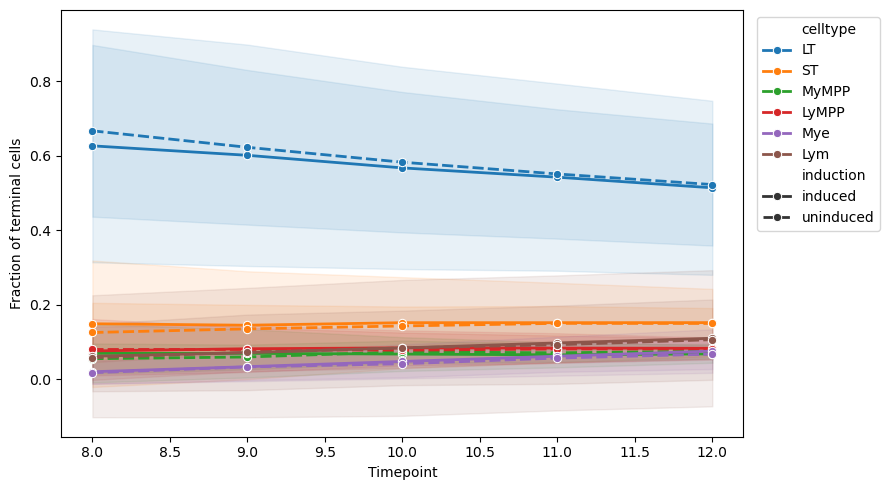

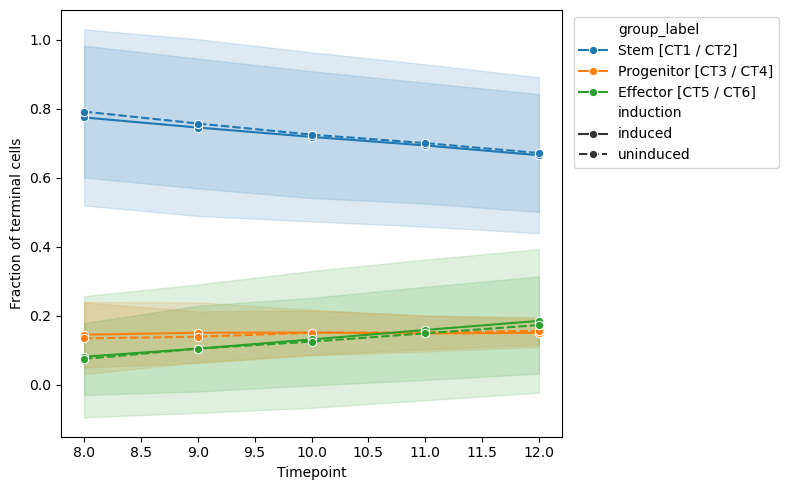

In [101]:
# cell type compositions:
import warnings

clade_assignment_path = clade_path
timepoints = all_timepoints
celltypes_ordered   = ['LT', 'ST', 'MyMPP', 'LyMPP', 'Mye', 'Lym']
ct_colors = dict(zip(celltypes_ordered, sns.color_palette('tab10', n_colors = len(celltypes_ordered))))

clade_assignments = pd.read_csv(clade_assignment_path, 
                                dtype={'urid': str, 'clade': str})

keep_clades = ['clade_differentiation_induced', 'clade_celltype', 'clade_alive', 'clade_terminal']
sub_ca = clade_assignments[clade_assignments['param_combo'].isin(keep_clades)].copy()
wide_sub = (sub_ca.pivot_table(index = ['urid','timepoint','linstring'],
                           columns = 'param_combo', values = 'clade',
                           aggfunc = 'first')
             .reset_index())
wide_sub.columns.name = None


ct_df_all = wide_sub[(wide_sub['clade_alive'] == 'True') & (wide_sub['clade_terminal'] == 'True')].copy()
ct_df_all['clade_differentiation_induced'] = ct_df_all['clade_differentiation_induced'] == 'True'

rows = []
for (urid, timepoint, induced), grp in ct_df_all.groupby(['urid','timepoint','clade_differentiation_induced']):
    ct = grp['clade_celltype'].value_counts()
    total = len(grp)
    rows.append({'urid': urid, 'timepoint': timepoint, 'induced': induced,
                 'total': total,
                 **{c: int(ct.get(c, 0)) for c in celltypes_ordered}})

ct_df = pd.DataFrame(rows)
for ct in celltypes_ordered:
    ct_df[f'frac_{ct}'] = ct_df[ct] / ct_df['total']
ct_df['frac_ct34'] = ct_df['frac_MyMPP'] + ct_df['frac_LyMPP']
ct_df['frac_ct56'] = ct_df['frac_Mye'] + ct_df['frac_Lym']
ct_df['frac_ct12'] = ct_df['frac_LT'] + ct_df['frac_ST']


count_tbl = (ct_df.groupby(['timepoint', 'induced'])[['total'] + celltypes_ordered]
             .mean().round(1))
count_tbl.index = count_tbl.index.set_levels(['uninduced', 'induced'], level = 'induced')

frac_cols = [f'frac_{c}' for c in celltypes_ordered]
frac_tbl = (ct_df.groupby(['timepoint', 'induced'])[frac_cols + ['frac_ct34','frac_ct56','frac_ct12']]
            .mean().round(4))
frac_tbl.columns = celltypes_ordered + ['CT3+CT4', 'CT5+CT6', 'CT1+CT2']
frac_tbl.index = frac_tbl.index.set_levels(['uninduced', 'induced'], level = 'induced')

frac_long = (ct_df
    .melt(id_vars = ['urid', 'timepoint', 'induced'],
          value_vars = [f'frac_{c}' for c in celltypes_ordered],
          var_name = 'celltype', 
          value_name = 'fraction')
    .assign(
        celltype  = lambda rowvals: rowvals['celltype'].str.replace('frac_', '', regex = False),
        induction = lambda rowvals: rowvals['induced'].map({True: 'induced', False: 'uninduced'})
    ))

def plot_ct_fractions(save = True):
    fig, ax = plt.subplots(figsize = (9, 5))
    sns.lineplot(
        data = frac_long,
        x = 'timepoint', y = 'fraction',
        hue = 'celltype', hue_order = celltypes_ordered,
        palette = ct_colors,
        style = 'induction', style_order = ['induced', 'uninduced'],
        marker = 'o', linewidth = 2,
        errorbar = 'sd', err_kws = {'alpha': 0.1},
        ax = ax
    )
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Fraction of terminal cells')
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', title = None)
    plt.tight_layout()
    if save:
        save_fig('celltype_composition', 'celltype_fractions_by_induction.png')
    plt.show()

plot_ct_fractions(save = True)

grouped_long = (ct_df
    .melt(id_vars = ['urid', 'timepoint', 'induced'],
          value_vars = ['frac_ct12', 'frac_ct34', 'frac_ct56'],
          var_name = 'grp', value_name = 'fraction')
    .assign(
        group_label = lambda rowvals: rowvals['grp'].map({
            'frac_ct12': 'Stem [CT1 / CT2]',
            'frac_ct34': 'Progenitor [CT3 / CT4]',
            'frac_ct56': 'Effector [CT5 / CT6]',
        }),
        induction = lambda rowvals: rowvals['induced'].map({True: 'induced', False: 'uninduced'})
    ))

def plot_ct_grouped(save = True):
    fig, ax = plt.subplots(figsize = (8, 5))
    sns.lineplot(
        data = grouped_long,
        x = 'timepoint', y = 'fraction',
        hue = 'group_label',
        style = 'induction', 
        style_order = ['induced', 'uninduced'],
        marker = 'o',
        errorbar = 'sd', err_kws = {'alpha': 0.15},
        ax = ax
    )
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Fraction of terminal cells')
    ax.legend(bbox_to_anchor = (1.01, 1), loc = 'upper left', title = None)
    plt.tight_layout()
    if save:
        save_fig('celltype_composition', 'celltype_progenitor_effector_by_induction.png')
    plt.show()

plot_ct_grouped(save = True)

mean_by_induced = ct_df.groupby('induced')[frac_cols].mean()
fold = (mean_by_induced.loc[True] / mean_by_induced.loc[False]).round(2)
fold.index = celltypes_ordered



In [102]:
os.makedirs('r_plots_input', exist_ok=True)


ann_purity_save = (
    ann_purity
    .assign(
        ff_del=lambda rowvals: rowvals['ff'] + '_' + rowvals['del'],
        savename=lambda rowvals: rowvals['urid'].map(urid_labels.set_index('urid')['savename']),
        scoremat_frac_of_gt=lambda rowvals: 1 - rowvals['relative_diff'],
    )
    [['urid','savename','model_code','ff','del','ff_del',
      'metric','gt_num_clades','mean_purity','mean_ari','abs_rel_diff','scoremat_frac_of_gt']]
)
ann_purity_save.to_csv('r_plots_input/ann_purity.csv', index=False)


_per_urid = (
    ann_purity_save
    .groupby(['urid','savename','model_code','ff','del','ff_del',
              'metric','gt_num_clades','mean_purity','mean_ari'])
    [['abs_rel_diff','scoremat_frac_of_gt']].mean().reset_index()
)
_agg = (
    _per_urid
    .groupby(['model_code','ff','del','ff_del','metric','gt_num_clades'])
    .agg(
        mean_abs_rel_diff   = ('abs_rel_diff',        'mean'),
        sem_abs_rel_diff    = ('abs_rel_diff',        lambda x: x.std(ddof=1) / max(len(x),1)**0.5),
        mean_frac_of_gt     = ('scoremat_frac_of_gt', 'mean'),
        sem_frac_of_gt      = ('scoremat_frac_of_gt', lambda x: x.std(ddof=1) / max(len(x),1)**0.5),
        mean_purity         = ('mean_purity',         'mean'),
        sem_purity          = ('mean_purity',         lambda x: x.std(ddof=1) / max(len(x),1)**0.5),
        mean_ari            = ('mean_ari',             'mean'),
        sem_ari             = ('mean_ari',             lambda x: x.std(ddof=1) / max(len(x),1)**0.5),
    )
    .reset_index()
)
_agg.to_csv('r_plots_input/agg_purity.csv', index=False)


stab_join.assign(ff_del=lambda d: d['ff'] + '_' + d['del']).to_csv(
    'r_plots_input/stab_join.csv', index=False)




In [103]:
# r_plots_input: helpers for focal-param detection and short-code ff/del encoding

ff_map_rplots = {'ff0': 'iso', 'ff2': 'mod', 'ff4': 'mix'}
del_map_rplots = {'del0': 'del0', 'del05': 'del50'}


def parse_savename_short(savename):
    '''
    Extract (model_code, ff, del) from savename using r_plots_input encoding.
    ff: iso / mod / mix  (not zero / moderate / mixed)
    del: del0 / del50   (not none / negative)
    '''
    parts = savename.split('_')
    model_code = parts[1]
    ff_part = next((p for p in parts if re.match(r'^ff\d$', p)), None)
    del_part = parts[-1]
    return (model_code,
            ff_map_rplots.get(ff_part, ff_part),
            del_map_rplots.get(del_part, del_part))


def rplots_rp(fname):
    m = re.search(r'_RP_([\d\.]+)[_\s]', fname)
    return float(m.group(1)) if m else None


def rplots_af(fname):
    m = re.search(r'_AF_([\d\.]+)[_\s]', fname)
    return float(m.group(1)) if m else None


def rplots_tp(fname):
    m = re.search(r'_time_(\d+)', fname)
    return int(m.group(1)) if m else None


def is_focal_params(fname, focal_rp = 1.0, focal_af = 0.0):
    rp = rplots_rp(fname)
    af = rplots_af(fname)
    return (rp is not None and af is not None
            and abs(rp - focal_rp) < 1e-9 and abs(af - focal_af) < 1e-9)


In [104]:
# r_plots_input/rf_dist_focal.csv and mt_mutation_counts.csv

rf_rows = []
mut_rows = []

for urid, savename in urid_to_savename_dict.items():
    model_code, ff, del_ = parse_savename_short(savename)

    rf_dir = Path(base_path) / urid / 'rf_dist_files' / urid
    if rf_dir.exists():
        for rf_file in rf_dir.glob('*_rf.txt'):
            if not is_focal_params(rf_file.name):
                continue
            tp = rplots_tp(rf_file.name)
            if tp is None:
                continue
            try:
                rf_dist_val = float(rf_file.read_text().splitlines()[0].strip())
            except ValueError:
                continue
            rf_rows.append({'urid': urid, 'timepoint': tp, 'rf_dist': rf_dist_val,
                            'model_code': model_code, 'ff': ff, 'del': del_})

    phylip_dir = Path(base_path) / urid / 'score_mats' / urid / 'phylips'
    if phylip_dir.exists():
        n_mut_counts = []
        for fasta in phylip_dir.glob('*.fasta'):
            if not is_focal_params(fasta.name):
                continue
            lines = fasta.read_text().splitlines()
            for i, line in enumerate(lines):
                if line.startswith('>') and i + 1 < len(lines):
                    seq = lines[i + 1].strip()
                    if seq:
                        n_mut_counts.append(len(seq))
                    break
        if n_mut_counts:
            mut_rows.append({'urid': urid, 'savename': savename,
                             'model_code': model_code, 'ff': ff, 'del': del_,
                             'n_mt_mutations': int(round(np.mean(n_mut_counts)))})


rf_dist_focal = (pd.DataFrame(rf_rows)
                 .sort_values(['urid', 'timepoint'])
                 .reset_index(drop = True))
rf_dist_focal.to_csv('r_plots_input/rf_dist_focal.csv', index = False)
print(f'rf_dist_focal.csv: {len(rf_dist_focal)} rows ({rf_dist_focal["urid"].nunique()} urids)')


mt_mutation_counts = (pd.DataFrame(mut_rows)
                      .sort_values('urid')
                      .reset_index(drop = True))
mt_mutation_counts.to_csv('r_plots_input/mt_mutation_counts.csv', index = False)
print(f'mt_mutation_counts.csv: {len(mt_mutation_counts)} rows')


rf_dist_focal.csv: 60 rows (12 urids)
mt_mutation_counts.csv: 12 rows


In [105]:
# r_plots_input/prauc_raw_and_ratio.csv and rocauc_raw_and_ratio.csv

sm_focal_combo = 'scoremat_min5_mt_250ints_1.0RP_0.0AF_TB_1-1-1-1-1-1'
gt_focal_combo = '5clade_topological_treedist_gt'

for metric, sm_col, out_name in [
    ('pr_auc',  'sm_pr',  'prauc_raw_and_ratio.csv'),
    ('roc_auc', 'sm_roc', 'rocauc_raw_and_ratio.csv'),
]:
    sub = em_metrics_df[em_metrics_df['metric'] == metric]

    sm = (sub[sub['param_combo'] == sm_focal_combo]
          .groupby(['urid', 'savename'])['value']
          .mean().reset_index()
          .rename(columns = {'value': sm_col}))

    gt = (sub[sub['param_combo'] == gt_focal_combo]
          .groupby('urid')['value']
          .mean().reset_index()
          .rename(columns = {'value': 'gt_val'}))

    merged = sm.merge(gt, on = 'urid', how = 'left')
    merged['ratio'] = merged[sm_col] / merged['gt_val'].replace(0, np.nan)
    merged = merged.drop(columns = ['gt_val'])

    parsed = merged['savename'].apply(parse_savename_short).apply(pd.Series)
    parsed.columns = ['model_code', 'ff', 'del']
    merged = pd.concat([merged, parsed], axis = 1)

    merged[['urid', sm_col, 'ratio', 'savename', 'model_code', 'ff', 'del']].to_csv(
        f'r_plots_input/{out_name}', index = False)
    print(f'{out_name}: {len(merged)} rows')


prauc_raw_and_ratio.csv: 12 rows
rocauc_raw_and_ratio.csv: 12 rows


In [106]:
# r_plots_input/sweep_clades_tmp.csv

sweep_parts = []
for chunk in pd.read_csv(clade_path, dtype = {'urid': str}, chunksize = 2_000_000):
    keep = chunk[chunk['urid'].isin(all_urids)].copy()
    if keep.shape[0] > 0:
        sweep_parts.append(keep[['urid', 'timepoint', 'param_combo', 'linstring', 'clade']])

sweep_clades = pd.concat(sweep_parts, ignore_index = True)
sweep_clades.to_csv('r_plots_input/sweep_clades_tmp.csv', index = False)
print(f'sweep_clades_tmp.csv: {len(sweep_clades):,} rows')


sweep_clades_tmp.csv: 2,475,732 rows
